Regression Tree from stratch


In [13]:
import matplotlib.pyplot as plt 
import numpy as np
from sklearn.tree import DecisionTreeRegressor

#taking data set

X = np.array([[500], [600], [700], [800], [900], [1000], [1100], [1200]])
y = np.array([10, 12, 14, 22, 24, 26, 28, 30])

In [31]:
tree = DecisionTreeRegressor(max_depth= 2)
tree.fit(X,y)

size = np.array([[550],[799],[900]])
print(f"predictions : {tree.predict(size)}")

predictions : [10. 23. 23.]


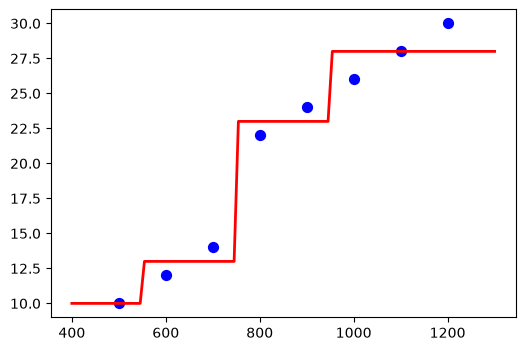

In [32]:
x_plot = np.linspace(400,1300,100).reshape(-1,1)
plt.figure(figsize=(6,4))
plt.plot(x_plot,tree.predict(x_plot),'r-',linewidth=2)
plt.scatter(X,y,c="b",s=50)
plt.show()


In [35]:
tree.score(X,y)*100

97.11191335740072

In [40]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100,max_depth=2)
rf.fit(X,y)



,n_estimators,100
,criterion,'gini'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
size = np.array([[550],[799],[900]])
print(f"predictions : {rf.predict(size)}")

predictions : [10 22 24]


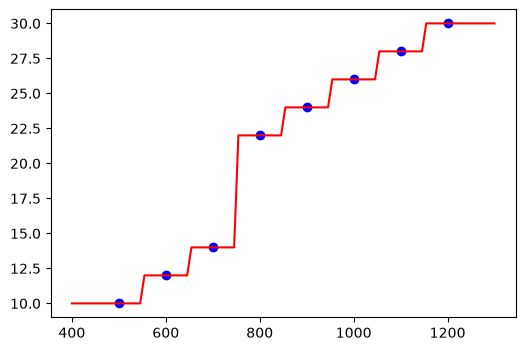

In [42]:
plt.figure(figsize=(6,4))
plt.plot(x_plot,rf.predict(x_plot),"r-")
plt.scatter(X,y,c="b")
plt.show()


Classification tree

In [45]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
x= np.array([[0,0],
             [0,1],
             [1,0],
             [1,1]])
y=np.array(["play","play","play","dont"])

tree = DecisionTreeClassifier(max_depth=2)
tree.fit(x,y)


,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


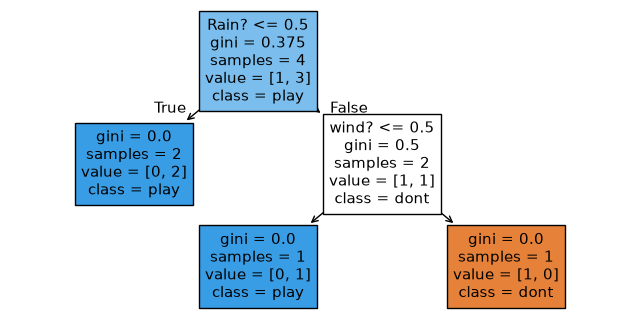

In [46]:
plt.figure(figsize=(8,4))
plot_tree(tree,filled=True,feature_names=["Rain?","wind?"],class_names=["dont","play"])
plt.show()

## Boosting 
### Adaboost - Adaptive Boosting

In [50]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split


x, y = make_moons(n_samples=200, noise=0.3, random_state=42)
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2,random_state=42)

ad = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    learning_rate=0.5,
    random_state=42
)
ad.fit(xtrain,ytrain)



,estimator,DecisionTreeC...r(max_depth=1)
,n_estimators,50
,learning_rate,0.5
,algorithm,'deprecated'
,random_state,42
,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [51]:
y_pred=ad.predict(xtest)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_5988\3640408811.py:24: UserWarning: You passed an edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(xtest[:, 0], xtest[:, 1], c=ytest, edgecolors='k',


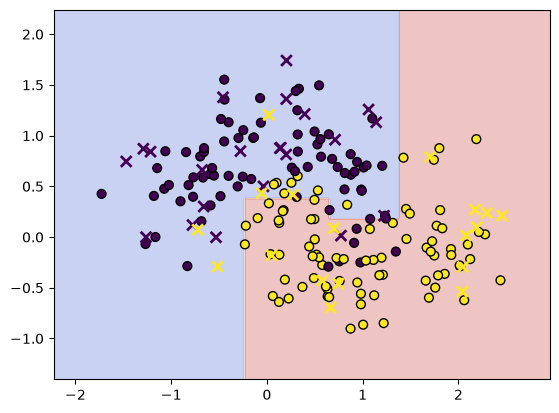

In [52]:
# 1. Get min/max of each feature, add 0.5 margin on both sides
x_min, x_max = x[:, 0].min() - 0.5, x[:, 0].max() + 0.5
y_min, y_max = x[:, 1].min() - 0.5, x[:, 1].max() + 0.5

# 2. Create a fine grid of points covering that rectangle
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),   # 200 evenly spaced x values
    np.linspace(y_min, y_max, 200)    # 200 evenly spaced y values
)
# xx, yy are now 200x200 matrices (40,000 points total)

# 3. Flatten grid, predict each point, reshape back to 200x200
Z = ad.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
# np.c_ = column-wise concatenation → 40,000 x 2 matrix
# .ravel() = flatten to 1D
# .reshape(xx.shape) = back to 200x200 grid

# 4. Fill contour with colors based on prediction
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
# alpha=0.3 = transparent so dots show through

# 5. Scatter actual data points on top
plt.scatter(xtrain[:, 0], xtrain[:, 1], c=ytrain, edgecolors='k', s=40)
plt.scatter(xtest[:, 0], xtest[:, 1], c=ytest, edgecolors='k',
            marker='x', s=60, linewidth=2)

In [53]:
from sklearn.tree import DecisionTreeRegressor
import numpy as np

# Data: y = 3x² + noise
X = np.random.rand(100, 1) - 0.5
y = 3 * X[:, 0] ** 2 + 0.05 * np.random.randn(100)

# Tree 1: predict y
tree_reg1 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg1.fit(X, y)

# Tree 2: predict residuals of Tree 1
y2 = y - tree_reg1.predict(X)
tree_reg2 = DecisionTreeRegressor(max_depth=2, random_state=43)
tree_reg2.fit(X, y2)

# Tree 3: predict residuals of Tree 1 + Tree 2
y3 = y2 - tree_reg2.predict(X)
tree_reg3 = DecisionTreeRegressor(max_depth=2, random_state=44)
tree_reg3.fit(X, y3)

# Final prediction = sum of all trees
X_new = np.array([[-0.4], [0.], [0.5]])
pred = sum(tree.predict(X_new) for tree in (tree_reg1, tree_reg2, tree_reg3))

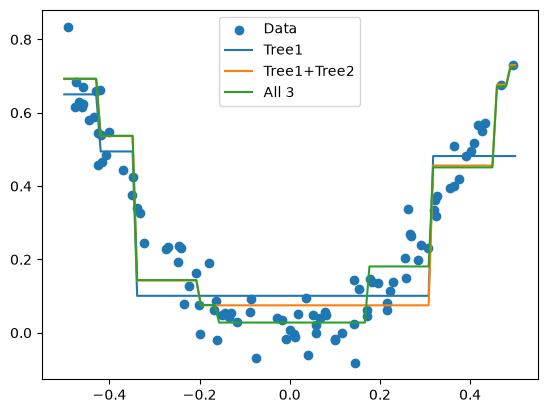

In [54]:
# Plot actual data
plt.scatter(X, y, label="Data")

# Generate smooth X values for the curve
X_plot = np.linspace(-0.5, 0.5, 100).reshape(-1, 1)

# Plot Tree 1 prediction
plt.plot(X_plot, tree_reg1.predict(X_plot), label="Tree1")

# Plot Tree 1 + Tree 2 prediction
plt.plot(X_plot, tree_reg1.predict(X_plot) + tree_reg2.predict(X_plot), label="Tree1+Tree2")

# Plot all three combined
plt.plot(X_plot, tree_reg1.predict(X_plot) + tree_reg2.predict(X_plot) + tree_reg3.predict(X_plot), label="All 3")

plt.legend()
plt.show()